OS DADOS FORAM GERADOS SINTETICAMENTE, MAS SEGUINDO ALGUMAS REGRAS.

É BEM DIFÍFCL QUE OS DADOS TENHAM ALGUM PROBLEMA, MAS É SEMPRE BOM VERIFICAR

In [1]:
import pandas as pd
import numpy as np

In [2]:
#CARREGANDO OS DADOS

dim_vendedor = pd.read_csv("../data/dim_vendedor.csv")
dim_cliente = pd.read_csv("../data/dim_cliente.csv")
dim_formapagamento = pd.read_csv("../data/dim_formapagamento.csv")
dim_produto = pd.read_csv("../data/dim_produto.csv")
dim_categoria = pd.read_csv("../data/dim_categoria.csv")
dim_data = pd.read_csv("../data/dim_data.csv")
fato_venda = pd.read_csv("../data/fato_venda.csv")

In [3]:
#ADICIONANDO OS DFs EM UM DICIONÁRIO

dicionario = {
    "clientes": dim_cliente,
    "vendedor": dim_vendedor,
    "produto": dim_produto,
    "formaPagamento": dim_formapagamento,
    "categoria": dim_categoria,
    "data": dim_data,
    "venda": fato_venda
}

In [4]:
#VERIFICANDO TAMANHO, COLUNAS, VALORES NULOS E DUPLICADOS

for nome, df in dicionario.items():
    print(f"---- {nome} ----")
    print(f"Tamanho: {df.shape}")
    print("----" * 10)
    print(f"Colunas: {df.columns}")
    print("----" * 10)
    print(f"Valores Nulos: \n{df.isnull().sum()}")
    print("----" * 10)
    print(f"Valores Duplicados: {df.duplicated().sum()}")
    print("\n")

---- clientes ----
Tamanho: (99, 6)
----------------------------------------
Colunas: Index(['id_cliente', 'nome', 'telefone', 'endereco', 'bairro', 'cpf'], dtype='str')
----------------------------------------
Valores Nulos: 
id_cliente    0
nome          0
telefone      0
endereco      0
bairro        0
cpf           0
dtype: int64
----------------------------------------
Valores Duplicados: 0


---- vendedor ----
Tamanho: (3, 2)
----------------------------------------
Colunas: Index(['id_vendedor', 'nome'], dtype='str')
----------------------------------------
Valores Nulos: 
id_vendedor    0
nome           0
dtype: int64
----------------------------------------
Valores Duplicados: 0


---- produto ----
Tamanho: (34, 6)
----------------------------------------
Colunas: Index(['id_produto', 'nome', 'precoCusto', 'precoVenda', 'quantidadeEstoque',
       'id_categoria'],
      dtype='str')
----------------------------------------
Valores Nulos: 
id_produto           0
nome           

In [5]:
#VERIFICANDO O TIPO DOS DADOS

for nome, df in dicionario.items():
    print(f"---- {nome} ----")
    print(df.dtypes)

---- clientes ----
id_cliente    int64
nome            str
telefone      int64
endereco        str
bairro          str
cpf           int64
dtype: object
---- vendedor ----
id_vendedor    int64
nome             str
dtype: object
---- produto ----
id_produto             int64
nome                     str
precoCusto           float64
precoVenda           float64
quantidadeEstoque      int64
id_categoria           int64
dtype: object
---- formaPagamento ----
id_formapag    int64
tipo             str
dtype: object
---- categoria ----
id_categoria    int64
nome              str
descricao         str
dtype: object
---- data ----
dataCompleta      str
dia             int64
mes             int64
nomeMes           str
ano             int64
diaSemana         str
dtype: object
---- venda ----
id_venda               int64
data                     str
id_cliente             int64
id_vendedor            int64
id_formapag            int64
id_produto             int64
quantidadeVendida      int64
desco

EXISTEM DIFERENÇAS NOS TIPOS DE ALGUNS DADOS, COMO EM TELEFONE, CPF E DATAS, MAS JÁ ERAM ESPERADAS, VISTO 
QUE AINDA NÃO FOI IMPLEMENTADO O MODELO FÍSICO

APESAR DISSO VAMOS VERIFICAR A COLUNA DE DATAS

In [6]:
#TENTA TRANSFORMAR OS VALORES EM DATA (SE RETORNAR 0, ESTÁ TUDO CERTO)

pd.to_datetime(fato_venda["data"], errors='coerce').isna().sum()

np.int64(0)

In [7]:
#O MESMO NA TABELA CALENDÁRIO AGORA

pd.to_datetime(dim_data["dataCompleta"], errors='coerce').isna().sum()

np.int64(0)

In [8]:
#VERIFICANDO OS DADOS NUMÉRICOS (ESPECIALMENTE VERIFICANDO OS IDs, SE O MÍNIMO E O MÁXIMO ESTÃO 
#DE ACORDO COM O TAMANHO DO DF - SENDO MÍNIMO 1 E O MÁXIMO IGUAL AO NÚMERO DE LINHAS

for nome, df in dicionario.items():
    print(f"---- {nome} ----")
    print(df.describe())
    print("----" * 10)
    print(f"Tamanho: {df.shape}")
    print("----" *10)
    print("\n")

#TAMBÉM MUITO IMPORTANTE POIS PODEMOS VERIFICAR SE OS DADOS NA TABELA DIM_DATA ESTÃO CORRETOS
#DIAS DE 1 A 31
#MÊS DE 1 A 8
#ANO = 2026

---- clientes ----
       id_cliente      telefone           cpf
count   99.000000  9.900000e+01  9.900000e+01
mean    50.000000  1.112223e+10  1.234565e+07
std     28.722813  2.872281e+01  2.872281e+01
min      1.000000  1.112223e+10  1.234560e+07
25%     25.500000  1.112223e+10  1.234562e+07
50%     50.000000  1.112223e+10  1.234565e+07
75%     74.500000  1.112223e+10  1.234567e+07
max     99.000000  1.112223e+10  1.234570e+07
----------------------------------------
Tamanho: (99, 6)
----------------------------------------


---- vendedor ----
       id_vendedor
count          3.0
mean           2.0
std            1.0
min            1.0
25%            1.5
50%            2.0
75%            2.5
max            3.0
----------------------------------------
Tamanho: (3, 2)
----------------------------------------


---- produto ----
       id_produto  precoCusto  precoVenda  quantidadeEstoque  id_categoria
count   34.000000   34.000000   34.000000          34.000000     34.000000
mean    

OS DADOS NUMÉRICOS ESTÃO COMO ESPERADOS, SEM VALORES NEGATIVOS ESPECIALMENTE NAS COLUNAS
QUANTIDADE VENDIDA, CUSTO TOTAL, DESCONTO, VALOR DE VENDA BRUTA DA TABELA
DE VENDAS (CASO HOUVESSE ESTARIA FERINDO AS REGRAS DE NEGÓCIO DA EMPRESA)

In [9]:
#VERIFICANDO INTEGRIDADE REFERENCIAL DO MODELO (SE AS RELAÇÕES ESTÃO CONSISTENTES) 

fato_venda[~fato_venda["id_produto"].isin(dim_produto["id_produto"])]

,id_venda,data,id_cliente,id_vendedor,id_formapag,id_produto,quantidadeVendida,desconto,custoTotal,valorVendaBruta


CASO RETORNASSE ALGUMA LINHA, TERÍAMOS VENDAS APONTANDO PARA PRODUTOS QUE NÃO EXISTEM

VOU FAZER O MESMO PROS OUTROS RELACIONAMENTOS

In [10]:
fato_venda[~fato_venda["id_cliente"].isin(dim_cliente["id_cliente"])]

,id_venda,data,id_cliente,id_vendedor,id_formapag,id_produto,quantidadeVendida,desconto,custoTotal,valorVendaBruta


In [11]:
fato_venda[~fato_venda["id_vendedor"].isin(dim_vendedor["id_vendedor"])]

,id_venda,data,id_cliente,id_vendedor,id_formapag,id_produto,quantidadeVendida,desconto,custoTotal,valorVendaBruta


In [12]:
fato_venda[~fato_venda["id_formapag"].isin(dim_formapagamento["id_formapag"])]

,id_venda,data,id_cliente,id_vendedor,id_formapag,id_produto,quantidadeVendida,desconto,custoTotal,valorVendaBruta


fato_venda[~fato_venda["data"].isin(dim_data["dataCompleta"])]

In [13]:
dim_produto[~dim_produto["id_categoria"].isin(dim_categoria["id_categoria"])]

,id_produto,nome,precoCusto,precoVenda,quantidadeEstoque,id_categoria


RELACIONAMENTOS ESTÃO CONSISTENTES

In [14]:
#VERIFICANDO A CONSISTÊNCIA DOS DADOS CATEGÓRICOS DE CATEGORIA, FORMA DE PAGAMENTO E VENDEDORES

dic_categ = {
    "categoria": dim_categoria["nome"],
    "tipo_formapagamento": dim_formapagamento["tipo"],
    "nome_vendedores": dim_vendedor["nome"]
}

for nome, cat in dic_categ.items():
    print(f"=== {nome} ===")
    print(cat.unique())

=== categoria ===
<ArrowStringArray>
['Ração', 'Acessórios', 'Brinquedos', 'Banho']
Length: 4, dtype: str
=== tipo_formapagamento ===
<ArrowStringArray>
['Dinheiro', 'PIX', 'Cartão Crédito', 'Cartão Débito']
Length: 4, dtype: str
=== nome_vendedores ===
<ArrowStringArray>
['Pablo', 'Allysson', 'Ingredi']
Length: 3, dtype: str


VERIFICANDO POSSÍVEIS OUTLIERS

In [16]:
dict_colunas_numericas = {
    "Quantidade Vendida": fato_venda["quantidadeVendida"],
    "Desconto": fato_venda["desconto"],
    "Custo Total": fato_venda["custoTotal"],
    "Valor Venda Bruto": fato_venda["valorVendaBruta"]
}

for nome, colunas in dict_colunas_numericas.items():
    q1 = colunas.quantile(0.25)
    q3 = colunas.quantile(0.75)

    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = (colunas < limite_inferior) | (colunas > limite_superior)

    print(f"\n{nome}")
    print(f"Q1: {q1}")
    print(f"Q3: {q3}")
    print(f"IQR: {iqr}")
    print(f"Limite inferior: {limite_inferior}")
    print(f"Limite superior: {limite_superior}")
    print(f"Quantidade de outliers: {outliers.sum()}")


Quantidade Vendida
Q1: 2.0
Q3: 4.0
IQR: 2.0
Limite inferior: -1.0
Limite superior: 7.0
Quantidade de outliers: 0

Desconto
Q1: 0.01
Q3: 0.04
IQR: 0.03
Limite inferior: -0.034999999999999996
Limite superior: 0.08499999999999999
Quantidade de outliers: 0

Custo Total
Q1: 11.25
Q3: 54.15
IQR: 42.9
Limite inferior: -53.099999999999994
Limite superior: 118.5
Quantidade de outliers: 859

Valor Venda Bruto
Q1: 19.6875
Q3: 94.7625
IQR: 75.075
Limite inferior: -92.92500000000001
Limite superior: 207.375
Quantidade de outliers: 792


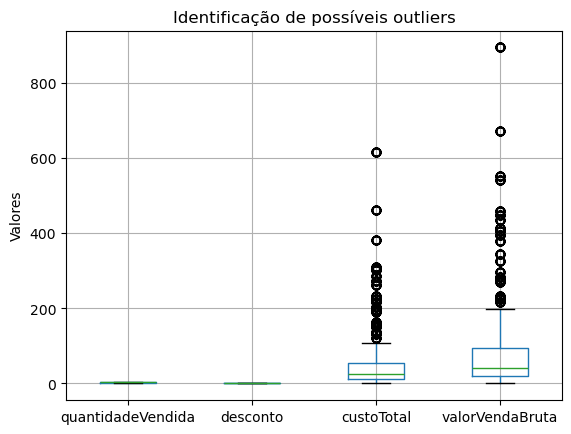

In [17]:
import matplotlib.pyplot as plt

fato_venda[["quantidadeVendida", "desconto", "custoTotal", "valorVendaBruta"]].boxplot()

plt.title("Identificação de possíveis outliers")
plt.ylabel("Valores")
plt.show()

EMBORA A ESTATÍSTICA TENHA MOSTRADO QUE EXISTA UMA QUANTIDADE SIGNIFICATIVA DE OUTLIERS

PELO MEU CONHECIMENTO DE NEGÓCIO, OS VALORES SÃO LEGÍTIMOS, POR EXEMPLO:

OS VALORES DAS VENDAS PODEM FICAR ALI EM MEDIA DE 100 A 200 REAIS, MAS VENDAS NOS VALORES DE 800 a 1000 PODEM 
PERFEITAMENTE ACONTECER. 

OS DADOS AO QUE TUDO INDICA ESTÃO CORRETOS E PRONTOS PARA SEREM ANALISADOS.